In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [50]:
dataset = pd.read_csv('WSN-DS[1].csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values
feature_names = dataset.columns[1:-1].tolist()  # Convert column names to a list
feature_names = np.array(feature_names)

In [51]:
print(X)
print(y)
print(feature_names)

[[5.0000000e+01 1.0000000e+00 1.0100000e+05 ... 1.3008535e+02
  0.0000000e+00 2.4694000e+00]
 [5.0000000e+01 0.0000000e+00 1.0104400e+05 ... 0.0000000e+00
  4.0000000e+00 6.9570000e-02]
 [5.0000000e+01 0.0000000e+00 1.0101000e+05 ... 0.0000000e+00
  3.0000000e+00 6.8980000e-02]
 ...
 [1.0030000e+03 0.0000000e+00 2.0109500e+05 ... 1.3926438e+02
  1.0000000e+00 9.4370000e-02]
 [1.0030000e+03 0.0000000e+00 2.0105100e+05 ... 1.5827492e+02
  3.0000000e+00 1.6047000e-01]
 [1.0250000e+03 0.0000000e+00 2.0210000e+05 ... 1.1500407e+02
  0.0000000e+00 1.0132500e+00]]
['Normal' 'Normal' 'Normal' ... 'Normal' 'Normal' 'Normal']
[' Time' ' Is_CH' ' who CH' ' Dist_To_CH' ' ADV_S' ' ADV_R' ' JOIN_S'
 ' JOIN_R' ' SCH_S' ' SCH_R' 'Rank' ' DATA_S' ' DATA_R' ' Data_Sent_To_BS'
 ' dist_CH_To_BS' ' send_code ' 'Expaned Energy']


In [52]:
from sklearn.impute import SimpleImputer
import numpy as np

# Impute all features (excluding target)
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X)  # Make sure X is full features

# Impute target if necessary (use most frequent)
imputer_y = SimpleImputer(strategy='most_frequent')
y = imputer_y.fit_transform(y.reshape(-1, 1)).ravel()


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

             Feature  Importance
1              Is_CH    0.478258
16    Expaned Energy    0.222971
8              SCH_S    0.104261
13   Data_Sent_To_BS    0.068650
4              ADV_S    0.053845
2             who CH    0.027641
7             JOIN_R    0.011319
5              ADV_R    0.007048
12            DATA_R    0.006610
14     dist_CH_To_BS    0.006306
0               Time    0.005965
3         Dist_To_CH    0.003820
10              Rank    0.002410
11            DATA_S    0.000361
15        send_code     0.000270
9              SCH_R    0.000264
6             JOIN_S    0.000000


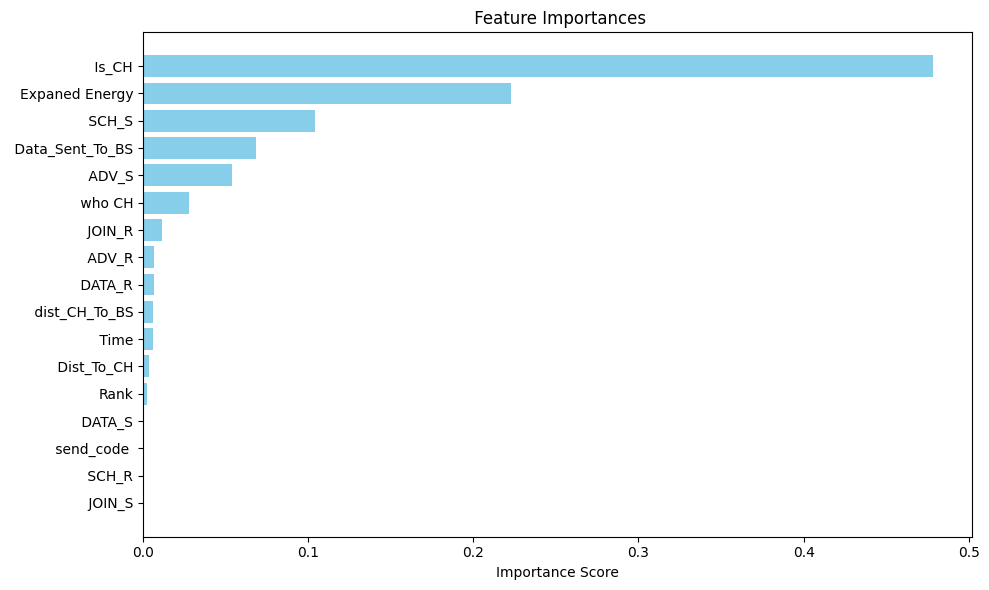

In [69]:
from sklearn.tree import DecisionTreeClassifier

# Fit your decision tree
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)

# Get feature importances
importances = clf.feature_importances_

# Pair with feature names
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title(' Feature Importances')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()

In [55]:
top_features = feature_importance_df['Feature'].head(8).tolist()
top_feature_indices = [np.where(feature_names == f)[0][0] for f in top_features]
X_train_selected = X_train[:, top_feature_indices]
X_test_selected= X_test[:, top_feature_indices]


In [56]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_selected = sc.fit_transform(X_train_selected)
X_test_selected = sc.transform(X_test_selected)

In [57]:
print(X_train_selected)

[[-0.36207183 -0.38417546 -0.10470656 ... -0.39916057 -0.15668353
  -0.55860705]
 [-0.36207183 -0.3644208  -0.10470656 ... -0.17335249 -0.15668353
  -0.41664236]
 [-0.36207183 -0.35600321 -0.10470656 ... -0.4299008  -0.15668353
  -0.55860705]
 ...
 [-0.36207183 -0.25832658 -0.10470656 ... -0.18869952 -0.15668353
  -0.13271298]
 [-0.36207183 -0.26115714 -0.10470656 ... -0.40161066 -0.15668353
   0.00925171]
 [-0.36207183 -0.10227515 -0.10470656 ...  0.58609189 -0.15668353
   0.00925171]]


In [58]:
print(X_test_selected)

[[-0.36207183 -0.13084753 -0.10470656 ... -0.43768207 -0.15668353
  -0.27467767]
 [-0.36207183 -0.41311833 -0.10470656 ... -0.43757688 -0.15668353
  -0.84253644]
 [-0.36207183 -0.30351184 -0.10470656 ... -0.44540946 -0.15668353
  -0.55860705]
 ...
 [-0.36207183 -0.06338826 -0.10470656 ... -0.15022933 -0.15668353
   0.00925171]
 [-0.36207183 -0.40089208 -0.10470656 ... -0.44288754 -0.15668353
  -0.70057175]
 [ 2.76188294  1.86669965  0.25614348 ...  0.58870104  0.05619187
   0.57711047]]


In [59]:

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train_selected, y_train)

DecisionTreeClassifier(random_state=42)

In [60]:
y_pred = classifier.predict(X_test_selected)

In [61]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9945284454112341


In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Blackhole       0.98      0.98      0.98      2010
    Flooding       0.93      0.94      0.94       662
    Grayhole       0.98      0.98      0.98      2919
      Normal       1.00      1.00      1.00     68014
        TDMA       0.92      0.94      0.93      1328

    accuracy                           0.99     74933
   macro avg       0.96      0.97      0.97     74933
weighted avg       0.99      0.99      0.99     74933



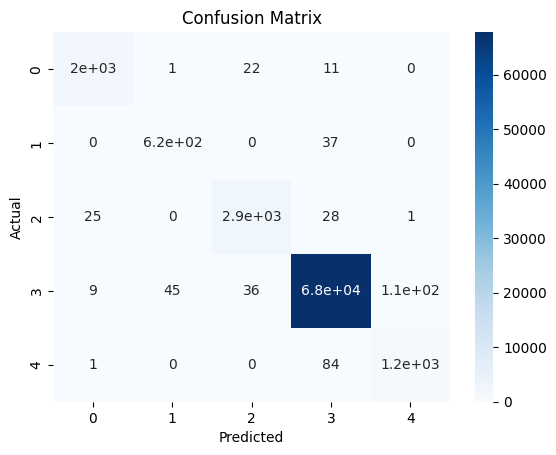

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()